### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [2]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_alumnos = pd.DataFrame(lista_alumnos, columns=["Nombre", "Edad", "Altura (m)"])
df_alumnos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Nombre      21 non-null     object 
 1   Edad        21 non-null     int64  
 2   Altura (m)  21 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 636.0+ bytes


In [5]:
df_alumnos.describe()

,Edad,Altura (m)
count,21.000000,21.000000
mean,32.095238,1.727143
std,6.081980,0.079003
min,23.000000,1.600000
25%,27.000000,1.660000
50%,32.000000,1.720000
75%,36.000000,1.800000
max,45.000000,1.900000


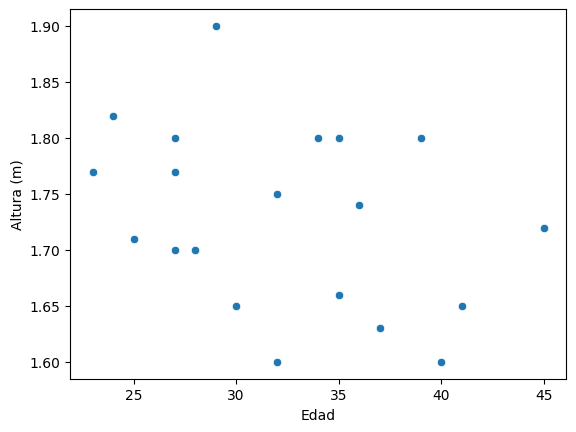

In [6]:
sns.scatterplot(df_alumnos, x="Edad", y="Altura (m)");

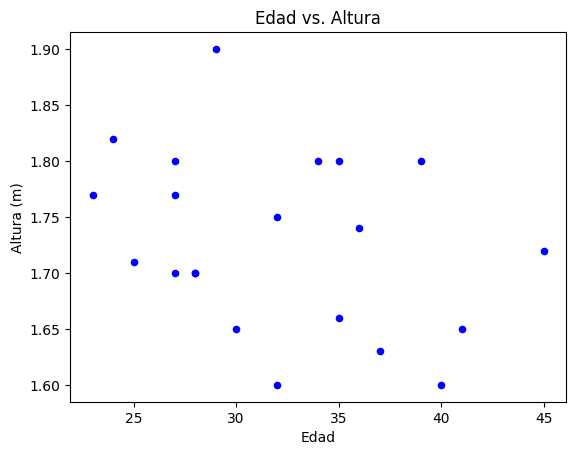

In [7]:
df_alumnos.plot.scatter(x="Edad", y="Altura (m)", color="blue", title="Edad vs. Altura")

plt.show() 

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [8]:
# NO ES UNA BUENA TÉCNICA, NO PODEMOS HACER TEST SI SOLO TENEMOS 21 DATOS

### Entrena un modelo de regresión lineal

In [ ]:
df_alumnos

In [ ]:
sns.pairplot(df_alumnos); 

NameError: name 'sns' is not defined

In [ ]:
sns.heatmap(df_alumnos.corr(numeric_only=True), annot=True); #INTENTAR PONER SIEMPRE EL BLANCO EN EL CERO

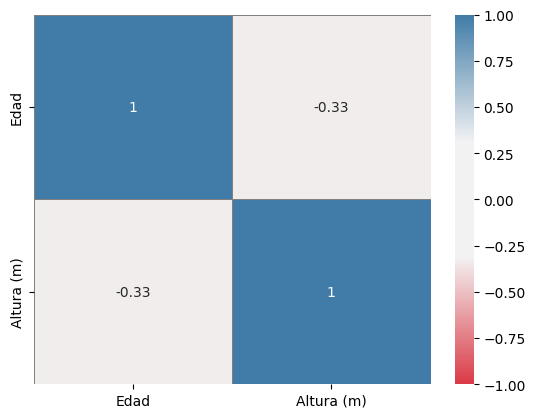

In [10]:
cmap = sns.diverging_palette(10, 240, sep=80, as_cmap=True)
sns.heatmap(df_alumnos.corr(numeric_only=True), annot=True, cmap=cmap, center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="gray");

In [ ]:
X = df_alumnos[['Edad']]
X

In [ ]:
y = df_alumnos['Altura (m)']
y
 

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 2, random_state = 10)

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
st_scaler = StandardScaler()
st_scaler.fit(X_train)
X_train_scaler = st_scaler.transform(X_train)

X_train_scaler

array([[ 0.37759563],
       [-0.49732107],
       [-0.14735439],
       [-1.02227108],
       [ 0.7275623 ],
       [-0.84728774],
       [-0.84728774],
       [ 1.25251232],
       [ 0.20261229],
       [ 0.37759563],
       [ 0.55257896],
       [ 1.42749566],
       [-1.37223776],
       [ 1.07752898],
       [-1.02227108],
       [-1.5472211 ],
       [-0.14735439],
       [-0.67230441],
       [ 2.12742901]])

In [ ]:
min_max_scaler = MinMaxScaler() #Normaliza todos los valores a 1
X_train_min_max = min_max_scaler.fit_transform(X_train)
X_train_min_max

array([[0.52380952],
       [0.28571429],
       [0.38095238],
       [0.14285714],
       [0.61904762],
       [0.19047619],
       [0.19047619],
       [0.76190476],
       [0.47619048],
       [0.52380952],
       [0.57142857],
       [0.80952381],
       [0.04761905],
       [0.71428571],
       [0.14285714],
       [0.        ],
       [0.38095238],
       [0.23809524],
       [1.        ]])

In [27]:
print('Tamaño X train', X_train.shape)
print('Tamaño y train', y_train.shape)
print('Tamaño X test', X_test.shape)
print('Tamaño y test', y_test.shape)

Tamaño X train (19, 1)
Tamaño y train (19,)
Tamaño X test (2, 1)
Tamaño y test (2,)


In [28]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

In [41]:
lm.fit(X_train_scaler, y_train)

LinearRegression()

In [31]:
X_test_scaler = st_scaler.transform(X_test)
predicciones = lm.predict (X_test_scaler)
predicciones

array([1.75779983, 1.74286514])

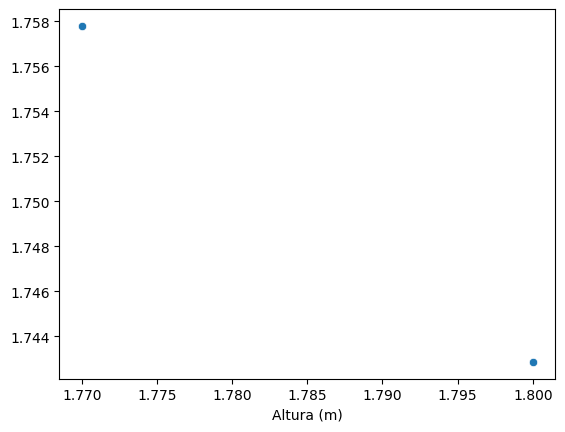

In [32]:
sns.scatterplot(x = y_test, y = predicciones);

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [34]:
from sklearn import metrics

In [35]:
lm.score(X_test_scaler, y_test)

-6.584969715921283

In [8]:
sns.displot((y_test - predicciones));

NameError: name 'y_test' is not defined

In [39]:
print('MAE:', metrics.mean_absolute_error(y_test, predicciones))
print('MAPE', metrics.mean_absolute_percentage_error(y_test, predicciones))
print('MSE:', metrics.mean_squared_error(y_test, predicciones))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predicciones)))

MAE: 0.0346675148430875
MAPE 0.019317170061768404
MSE: 0.0017066181860822917
RMSE: 0.04131123559132904


In [40]:
#MANUALMENTE
mae = abs(y_test - predicciones).mean()
mse = ((y_test - predicciones)**2).mean()
mape = abs((y_test - predicciones)/y_test).mean()
print ('MAE:', mae)
print ('MSE:', mse)
print ('MAPE:', mape)

MAE: 0.0346675148430875
MSE: 0.0017066181860822917
MAPE: 0.019317170061768404
